In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data

data = pd.read_csv('/Users/amelialuongo/Desktop/comp bme/Module-4-Cancer/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)
metadata_df = pd.read_csv('/Users/amelialuongo/Desktop/comp bme/Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)
# Subset the data for a specific cancer type

cancer_type = ['CESC', 'OV', 'BRCA', 'UCEC', 'UCS']

# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
# Then grab the index of this subset (these are the sample IDs)
cancer_samples = metadata_df[metadata_df['cancer_type'].isin(cancer_type)].index
# Subset the main data to include only these samples
# When you want a subset of columns, you can pass a list of column names to the data frame in []
cancer_data = data[cancer_samples]

# Subset by index (genes)

# Load gene list from Menyhart hallmarks file and extract metastasis row
hallmarks = {}
with open('/Users/amelialuongo/Desktop/comp bme/Module-4-Cancer/data/Menyhart_JPA_CancerHallmarks_core.csv') as f:
    for line in f:
        parts = line.strip().strip('"').split('\t')
        hallmarks[parts[0]] = parts[1:]

desired_gene_list = hallmarks['TISSUE INVASION AND METASTASIS']

gene_list = [gene for gene in desired_gene_list if gene in cancer_data.index]

# .loc[] is the method to subset by index labels
# .iloc[] will subset by index position (integer location) instead
cancer_gene_data = cancer_data.loc[gene_list]

print(gene_list)
print(f"\nTotal: {len(gene_list)} genes")

# Merging datasets

# Merge the subsetted expression data with metadata for BRCA samples,
# so rows are samples and columns include gene expression for EGFR and MYC and metadata
cancer_metadata = metadata_df.loc[cancer_samples]
cancer_merged = cancer_gene_data.T.merge(
    cancer_metadata, left_index=True, right_index=True)




['ANGPTL3', 'CXCR4', 'LAMA4', 'EFNB1', 'MAP3K8', 'RHOA', 'TBL1XR1', 'WNT5B', 'LAMA5', 'ITGA2B', 'SDC1', 'NGF', 'NFKB2', 'NTNG1', 'HCK', 'PDPK1', 'CDH5', 'WNT10A', 'MAPKAPK2', 'PIP5K1C', 'CDC42BPA', 'ABL2', 'RAB11A', 'TGFA', 'ARRB1', 'ITGA5', 'PLCG1', 'RASA1', 'RRAS', 'ENG', 'CLDN15', 'PIK3CD', 'LAMB2', 'CNR1', 'WAS', 'CLDN20', 'FPR2', 'PARD3', 'SDC3', 'ELMO2', 'GP1BA', 'FYN', 'LIMK1', 'PXN', 'MAP3K2', 'XIAP', 'ERBB3', 'CD6', 'NRXN2', 'PRKACB', 'GFRA1', 'TNF', 'PRKACA', 'S1PR1', 'ITGB1', 'PLXND1', 'DUSP1', 'BAMBI', 'COL6A3', 'NTF3', 'MMP7', 'CDC42', 'RAPGEF1', 'PTEN', 'FGF10', 'CD34', 'FLNA', 'ALCAM', 'CRKL', 'LAMC1', 'AKT1', 'IRS2', 'SMAD2', 'CAV1', 'MADCAM1', 'BMP7', 'ACTR2', 'CD44', 'CLDN3', 'TLR2', 'ID1', 'GNG2', 'LAMB1', 'GNA12', 'ITGAL', 'EFNA3', 'NCKAP1', 'SPHK1', 'WNT9A', 'SSX2IP', 'DPP4', 'NLGN2', 'CTNNA1', 'PRKCD', 'PLCB3', 'EPHB2', 'CASP8', 'TRIP6', 'FGFR1', 'EFNA1', 'GNB5', 'MYH9', 'EPHB1', 'ITGB2', 'CBL', 'CNTNAP1', 'FAT1', 'NRXN1', 'ARHGEF7', 'CD99', 'NTRK2', 'JUP', 'NCAM1

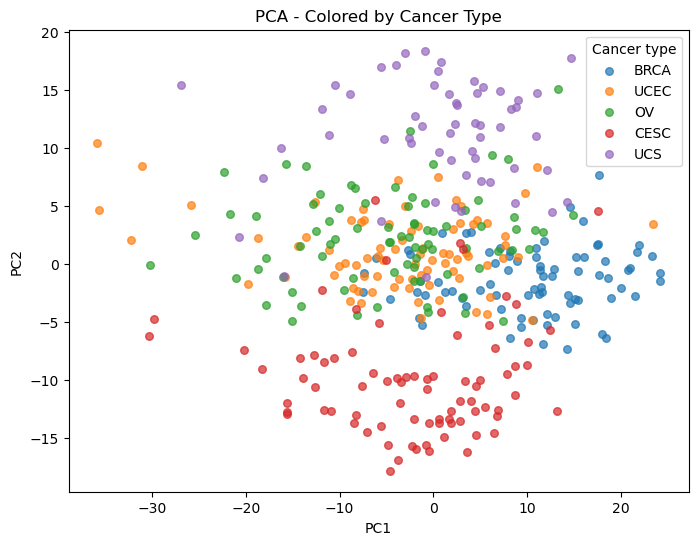

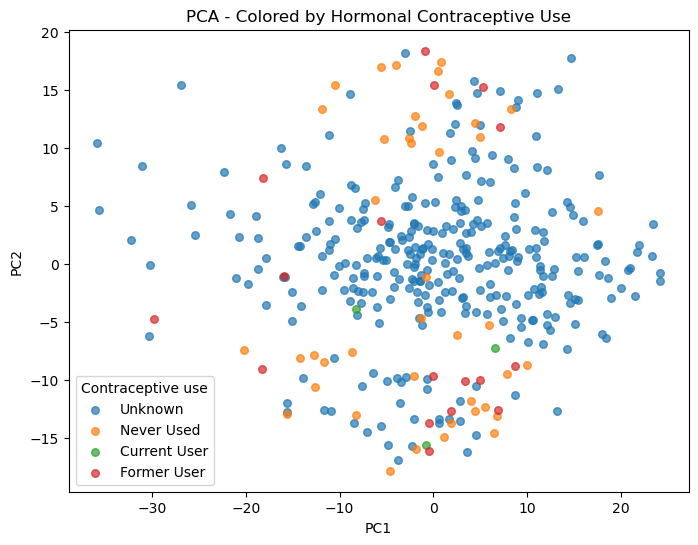

In [2]:
# Prepare data for PCA

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Transpose so rows=samples, columns=genes, then scale
X = cancer_gene_data.T
X_scaled = StandardScaler().fit_transform(X)


# Run PCA and plot - colored by cancer type

X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

cancer_labels = metadata_df.loc[X.index, 'cancer_type']

fig, ax = plt.subplots(figsize=(8, 6))
for ctype in cancer_labels.unique():
    mask = cancer_labels == ctype
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=ctype, alpha=0.7, s=30)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA - Colored by Cancer Type')
ax.legend(title='Cancer type')
plt.show()


# PCA - colored by hormonal contraceptive use

hormone_labels = metadata_df.loc[X.index, 'history_hormonal_contraceptives_use']
hormone_labels = hormone_labels.fillna('Unknown').replace(['[Not Available]', '[Unknown]'], 'Unknown')

fig, ax = plt.subplots(figsize=(8, 6))
for val in hormone_labels.unique():
    mask = hormone_labels == val
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=val, alpha=0.7, s=30)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA - Colored by Hormonal Contraceptive Use')
ax.legend(title='Contraceptive use')
plt.show()

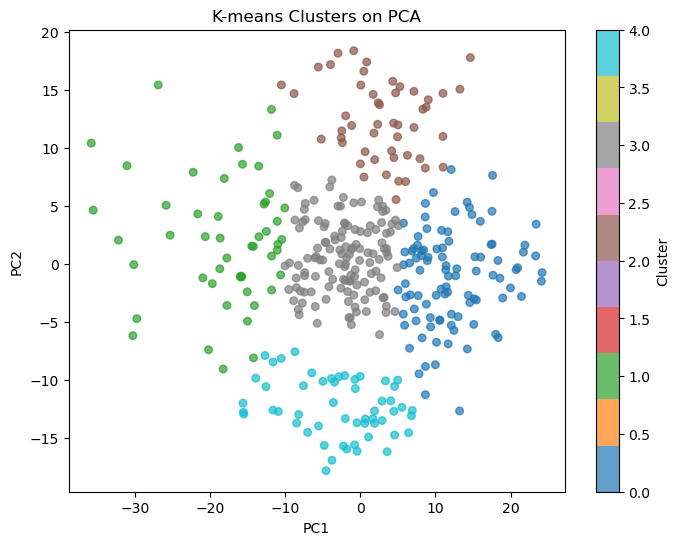

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


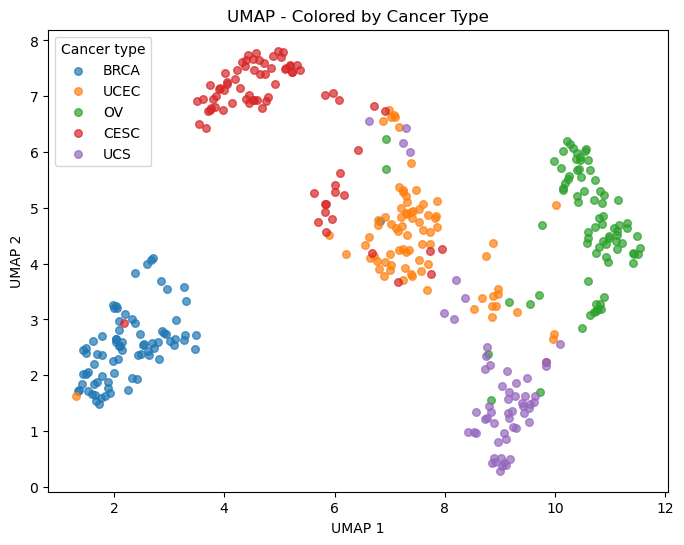

In [3]:

# K-means clustering on PCA

from sklearn.cluster import KMeans

km = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_pca)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.7, s=30)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('K-means Clusters on PCA')
plt.colorbar(scatter, label='Cluster')
plt.show()

# UMAP

import umap

X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for ctype in cancer_labels.unique():
    mask = cancer_labels == ctype
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1], label=ctype, alpha=0.7, s=30)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP - Colored by Cancer Type')
ax.legend(title='Cancer type')
plt.show()


Training samples  : 377
Validation samples: 320
Features (genes)  : 596

In-sample  error  (training)  : 0.0902  (9.02%)
Out-of-sample error (validation): 0.2344  (23.44%)

In-sample  accuracy : 0.9098
Out-of-sample accuracy: 0.7656


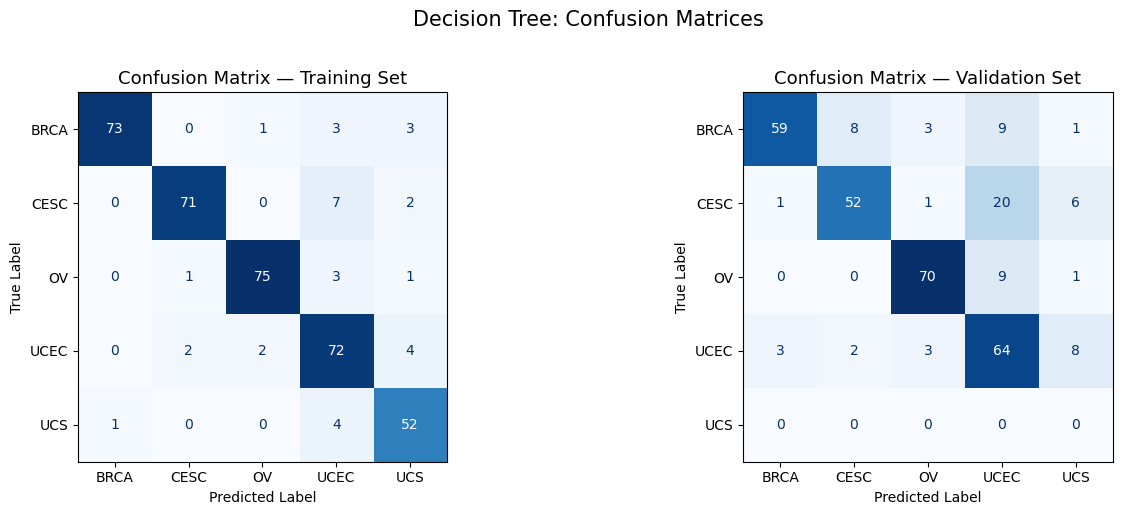


Classification Report — Validation Set
              precision    recall  f1-score   support

        BRCA       0.94      0.74      0.83        80
        CESC       0.84      0.65      0.73        80
          OV       0.91      0.88      0.89        80
        UCEC       0.63      0.80      0.70        80
         UCS       0.00      0.00      0.00         0

    accuracy                           0.77       320
   macro avg       0.66      0.61      0.63       320
weighted avg       0.83      0.77      0.79       320



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


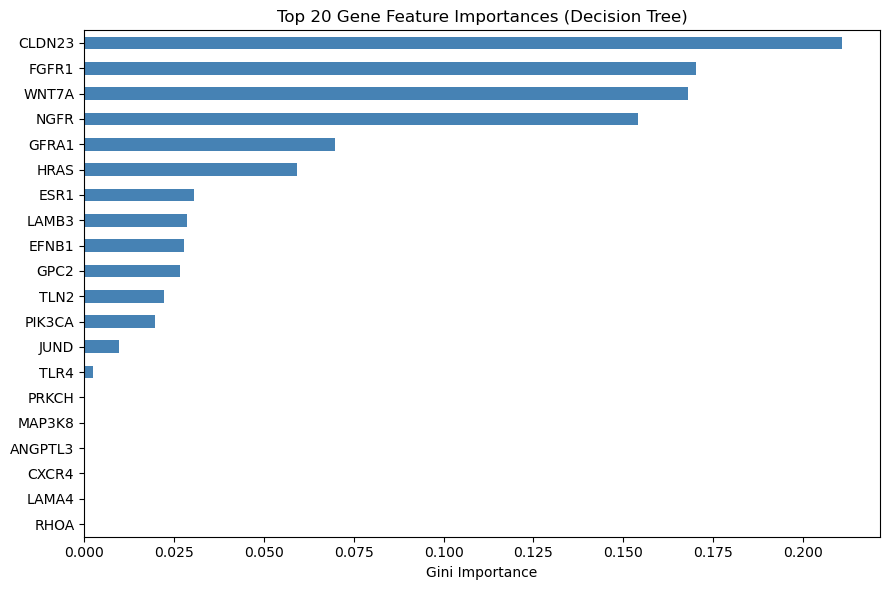

In [4]:
# ============================================================
# DECISION TREE CLASSIFICATION
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, ConfusionMatrixDisplay
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. Load the true validation set ─────────────────────────
val_data = pd.read_csv('/Users/amelialuongo/Desktop/comp bme/Module-4-Cancer/data/VALIDATION_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)
val_metadata = pd.read_csv('/Users/amelialuongo/Desktop/comp bme/Module-4-Cancer/data/VALIDATION_SET_GSE62944_metadata.csv', index_col=0, header=0)

# ── 2. Subset validation set to same cancer types & genes ───
val_cancer_samples = val_metadata[val_metadata['cancer_type'].isin(cancer_type)].index
val_cancer_data = val_data[val_cancer_samples]
val_gene_data = val_cancer_data.loc[gene_list]   # same metastasis genes as training

# ── 3. Prepare training features and labels ─────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(cancer_gene_data.T)   # fit ONLY on training data
X_val   = scaler.transform(val_gene_data.T)          # transform only, no refit

y_train = metadata_df.loc[cancer_gene_data.T.index, 'cancer_type'].values
y_val   = val_metadata.loc[val_gene_data.T.index, 'cancer_type'].values

print(f"Training samples  : {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Features (genes)  : {X_train.shape[1]}")

# ── 4. Fit Decision Tree on full training set ────────────────
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)

# ── 5. Predictions ───────────────────────────────────────────
y_train_pred = dt.predict(X_train)
y_val_pred   = dt.predict(X_val)

# ── 6. Error rates ───────────────────────────────────────────
train_error = 1 - accuracy_score(y_train, y_train_pred)
val_error   = 1 - accuracy_score(y_val,   y_val_pred)

print(f"\nIn-sample  error  (training)  : {train_error:.4f}  ({train_error*100:.2f}%)")
print(f"Out-of-sample error (validation): {val_error:.4f}  ({val_error*100:.2f}%)")
print(f"\nIn-sample  accuracy : {1-train_error:.4f}")
print(f"Out-of-sample accuracy: {1-val_error:.4f}")

# ── 7. Confusion Matrices ────────────────────────────────────
class_order = sorted(np.unique(y_train))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (preds, true, title) in zip(
    axes,
    [(y_train_pred, y_train, "Training Set"),
     (y_val_pred,   y_val,   "Validation Set")]
):
    cm = confusion_matrix(true, preds, labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"Confusion Matrix — {title}", fontsize=13)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Decision Tree: Confusion Matrices", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# ── 8. Classification Report ─────────────────────────────────
print("\nClassification Report — Validation Set")
print("=" * 55)
print(classification_report(y_val, y_val_pred, target_names=class_order))

# ── 9. Feature Importance (top 20 genes) ─────────────────────
importances = pd.Series(dt.feature_importances_, index=gene_list)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Top 20 Gene Feature Importances (Decision Tree)")
ax.set_xlabel("Gini Importance")
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best hyperparameters: {'ccp_alpha': 0.0, 'max_depth': 5, 'min_samples_leaf': 15}
Best CV accuracy    : 0.7853

Original model
  In-sample error    (train) : 0.0902  (9.02%)
  Out-of-sample error  (val) : 0.2344  (23.44%)

Refined model
  In-sample error    (train) : 0.1512  (15.12%)
  Out-of-sample error  (val) : 0.2594  (25.94%)

Test samples : 320

── Final Refined Model Error Summary ──────────────────
  In-sample error      (train) : 0.1512  (15.12%)
  Out-of-sample error    (val) : 0.2594  (25.94%)
  Test error            (test) : 0.2188  (21.88%)


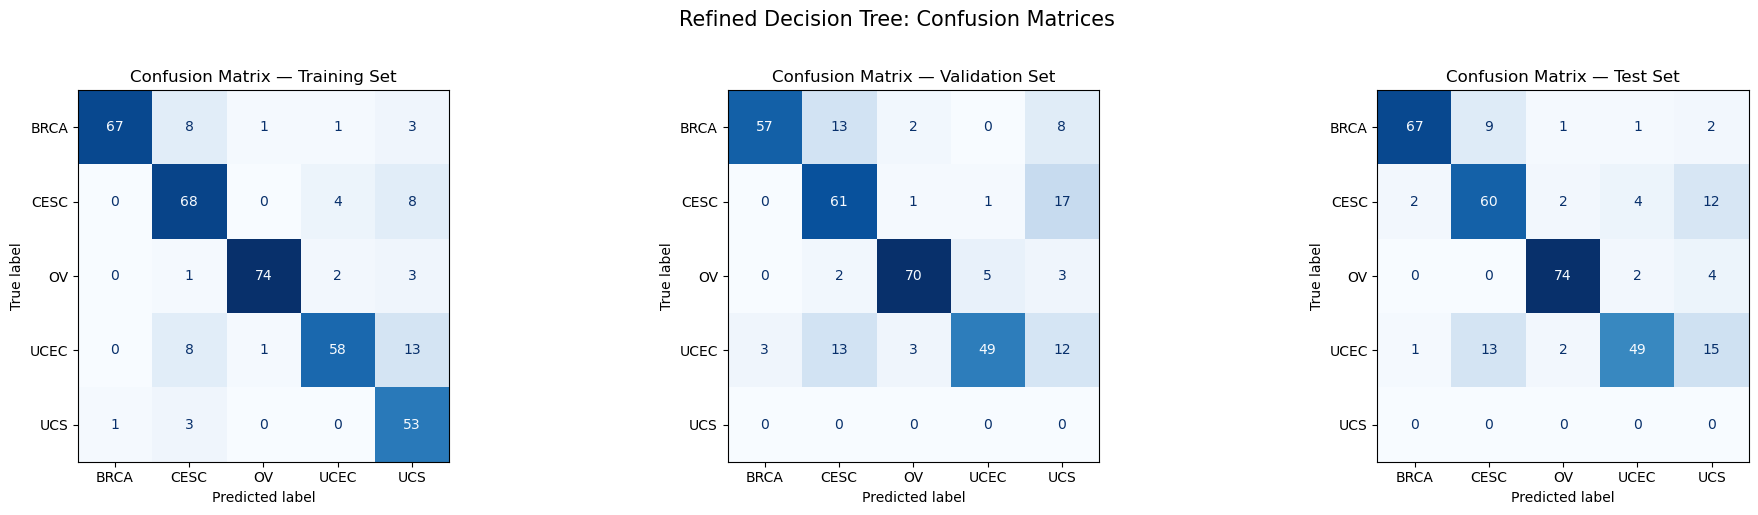


Classification Report — Test Set
              precision    recall  f1-score   support

        BRCA       0.96      0.84      0.89        80
        CESC       0.73      0.75      0.74        80
          OV       0.94      0.93      0.93        80
        UCEC       0.88      0.61      0.72        80
         UCS       0.00      0.00      0.00         0

    accuracy                           0.78       320
   macro avg       0.70      0.62      0.66       320
weighted avg       0.88      0.78      0.82       320



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


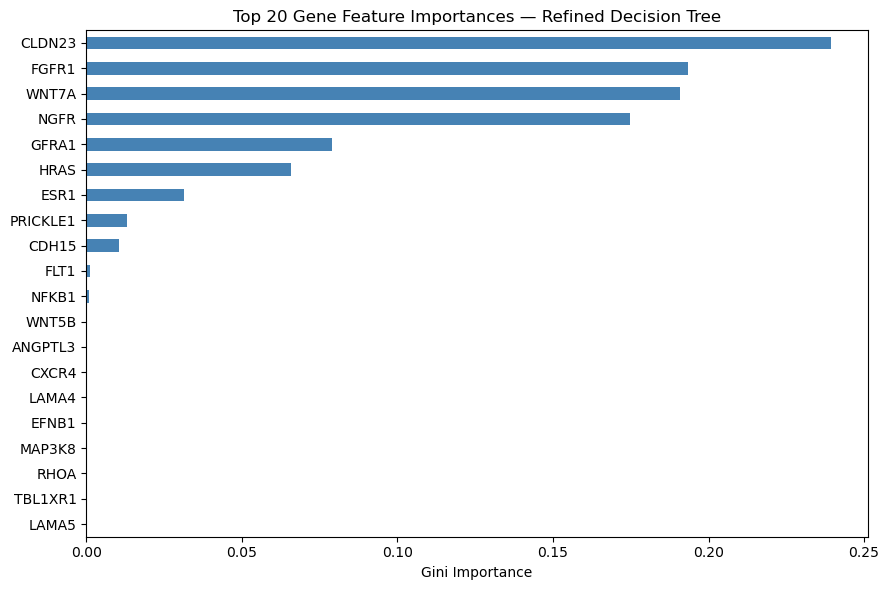

In [5]:
# ============================================================
# MODEL REFINEMENT + TEST SET EVALUATION
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, ConfusionMatrixDisplay
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. Regularization via GridSearchCV on training data ──────
# These hyperparameters all act as regularization:
#   max_depth        → limits tree complexity
#   min_samples_leaf → prevents overfitting to tiny groups
#   ccp_alpha        → cost-complexity pruning (explicit regularization)

param_grid = {
    'max_depth'        : [3, 5, 7, 10],
    'min_samples_leaf' : [3, 5, 10, 15],
    'ccp_alpha'        : [0.0, 0.001, 0.005, 0.01]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,                  # 5-fold cross-validation on training set
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print(f"Best CV accuracy    : {grid_search.best_score_:.4f}")

# ── 2. Refit best model and compare to original on validation ─
dt_original = DecisionTreeClassifier(
    max_depth=5, min_samples_leaf=5,
    class_weight='balanced', random_state=42
).fit(X_train, y_train)

dt_best = grid_search.best_estimator_   # already fit on full X_train

for name, model in [("Original model", dt_original), ("Refined model", dt_best)]:
    tr_err  = 1 - accuracy_score(y_train, model.predict(X_train))
    val_err = 1 - accuracy_score(y_val,   model.predict(X_val))
    print(f"\n{name}")
    print(f"  In-sample error    (train) : {tr_err:.4f}  ({tr_err*100:.2f}%)")
    print(f"  Out-of-sample error  (val) : {val_err:.4f}  ({val_err*100:.2f}%)")

# ── 3. Load test set ─────────────────────────────────────────
test_data     = pd.read_csv('/Users/amelialuongo/Desktop/comp bme/Module-4-Cancer/data/TEST_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)
test_metadata = pd.read_csv('/Users/amelialuongo/Desktop/comp bme/Module-4-Cancer/data/TEST_SET_GSE62944_metadata.csv', index_col=0, header=0)

# Subset to same cancer types and same metastasis genes
test_cancer_samples = test_metadata[test_metadata['cancer_type'].isin(cancer_type)].index
test_cancer_data    = test_data[test_cancer_samples]
test_gene_data      = test_cancer_data.loc[gene_list]

# Scale using the SAME scaler fit on training data (no refit)
X_test = scaler.transform(test_gene_data.T)
y_test = test_metadata.loc[test_gene_data.T.index, 'cancer_type'].values

print(f"\nTest samples : {X_test.shape[0]}")

# ── 4. Final predictions on test set ─────────────────────────
y_test_pred = dt_best.predict(X_test)

test_error    = 1 - accuracy_score(y_test, y_test_pred)
train_error   = 1 - accuracy_score(y_train, dt_best.predict(X_train))
val_error     = 1 - accuracy_score(y_val,   dt_best.predict(X_val))

print("\n── Final Refined Model Error Summary ──────────────────")
print(f"  In-sample error      (train) : {train_error:.4f}  ({train_error*100:.2f}%)")
print(f"  Out-of-sample error    (val) : {val_error:.4f}  ({val_error*100:.2f}%)")
print(f"  Test error            (test) : {test_error:.4f}  ({test_error*100:.2f}%)")

# ── 5. Confusion matrices: all three splits side by side ─────
class_order = sorted(np.unique(y_train))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (preds, true, title) in zip(
    axes,
    [(dt_best.predict(X_train), y_train, "Training Set"),
     (dt_best.predict(X_val),   y_val,   "Validation Set"),
     (y_test_pred,              y_test,  "Test Set")]
):
    cm   = confusion_matrix(true, preds, labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"Confusion Matrix — {title}", fontsize=12)

plt.suptitle("Refined Decision Tree: Confusion Matrices", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# ── 6. Classification report on test set ─────────────────────
print("\nClassification Report — Test Set")
print("=" * 55)
print(classification_report(y_test, y_test_pred, target_names=class_order))

# ── 7. Feature importance (top 20 genes) ─────────────────────
importances = pd.Series(dt_best.feature_importances_, index=gene_list)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Top 20 Gene Feature Importances — Refined Decision Tree")
ax.set_xlabel("Gini Importance")
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}
Best CV accuracy    : 0.9257

── Error Comparison ───────────────────────────────────

  Original Decision Tree
    In-sample error    (train) : 0.0902  (9.02%)
    Out-of-sample error  (val) : 0.2344  (23.44%)

  Random Forest (refined)
    In-sample error    (train) : 0.0000  (0.00%)
    Out-of-sample error  (val) : 0.0469  (4.69%)

── Final Random Forest Error Summary ──────────────────
  In-sample error      (train) : 0.0000  (0.00%)
  Out-of-sample error    (val) : 0.0469  (4.69%)
  Test error            (test) : 0.0531  (5.31%)


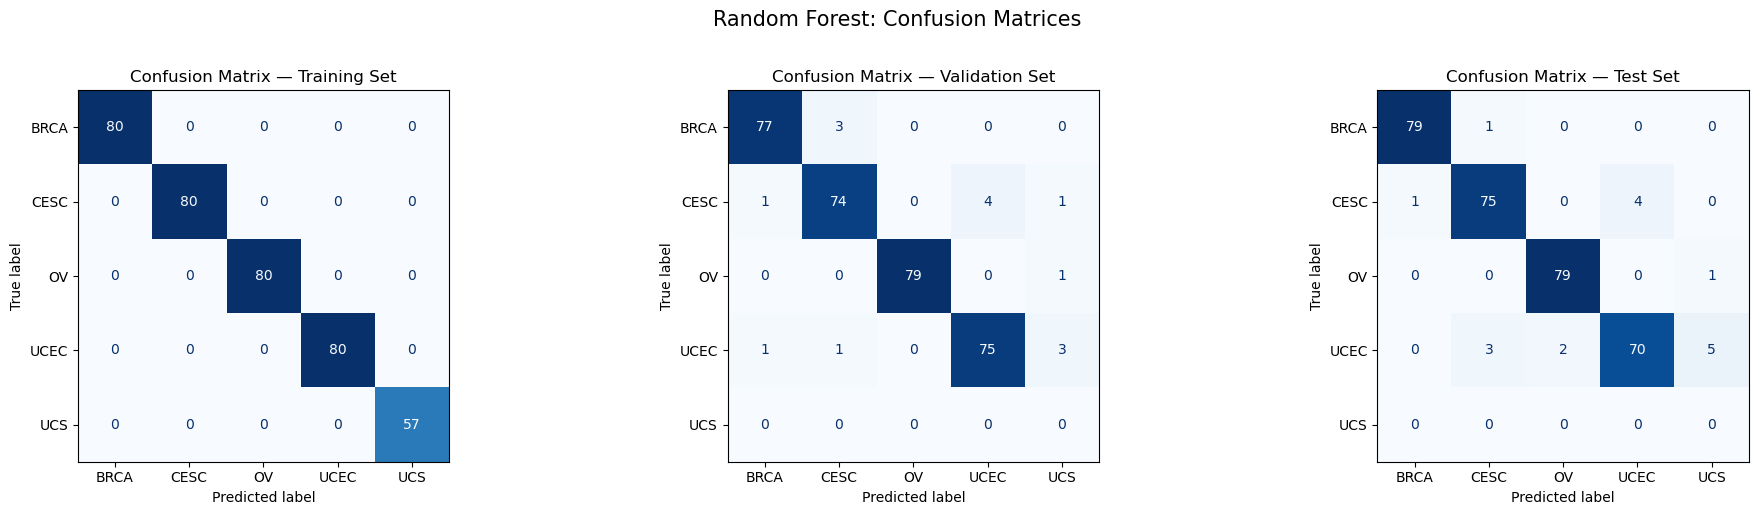


Classification Report — Test Set
              precision    recall  f1-score   support

        BRCA       0.99      0.99      0.99        80
        CESC       0.95      0.94      0.94        80
          OV       0.98      0.99      0.98        80
        UCEC       0.95      0.88      0.91        80
         UCS       0.00      0.00      0.00         0

    accuracy                           0.95       320
   macro avg       0.77      0.76      0.76       320
weighted avg       0.96      0.95      0.96       320



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


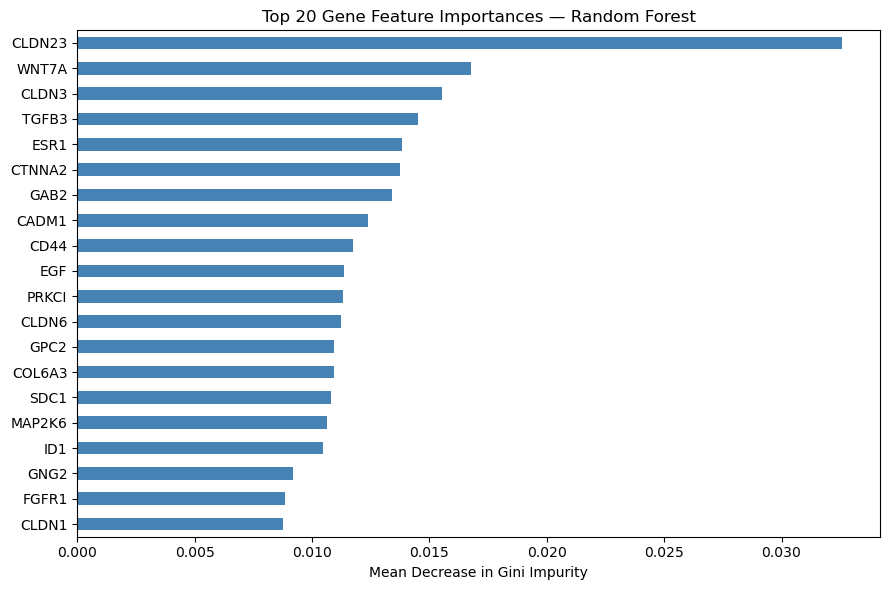

In [6]:
# ============================================================
# IMPROVED MODEL — RANDOM FOREST (better regularization)
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── 1. Grid search over Random Forest hyperparameters ────────
param_grid = {
    'n_estimators'     : [100, 200],      # number of trees
    'max_depth'        : [3, 5, 10, None],# None = fully grown trees
    'min_samples_leaf' : [2, 5, 10],      # regularization per tree
    'max_features'     : ['sqrt', 'log2'] # features considered per split
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf, param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print(f"Best CV accuracy    : {grid_search.best_score_:.4f}")

rf_best = grid_search.best_estimator_

# ── 2. Compare original DT vs Random Forest ──────────────────
dt_original = DecisionTreeClassifier(
    max_depth=5, min_samples_leaf=5,
    class_weight='balanced', random_state=42
).fit(X_train, y_train)

print("\n── Error Comparison ───────────────────────────────────")
for name, model in [("Original Decision Tree", dt_original),
                    ("Random Forest (refined)", rf_best)]:
    tr_err  = 1 - accuracy_score(y_train, model.predict(X_train))
    val_err = 1 - accuracy_score(y_val,   model.predict(X_val))
    print(f"\n  {name}")
    print(f"    In-sample error    (train) : {tr_err:.4f}  ({tr_err*100:.2f}%)")
    print(f"    Out-of-sample error  (val) : {val_err:.4f}  ({val_err*100:.2f}%)")

# ── 3. Final predictions on test set ─────────────────────────
y_test_pred   = rf_best.predict(X_test)
test_error    = 1 - accuracy_score(y_test, y_test_pred)
train_error   = 1 - accuracy_score(y_train, rf_best.predict(X_train))
val_error     = 1 - accuracy_score(y_val,   rf_best.predict(X_val))

print("\n── Final Random Forest Error Summary ──────────────────")
print(f"  In-sample error      (train) : {train_error:.4f}  ({train_error*100:.2f}%)")
print(f"  Out-of-sample error    (val) : {val_error:.4f}  ({val_error*100:.2f}%)")
print(f"  Test error            (test) : {test_error:.4f}  ({test_error*100:.2f}%)")

# ── 4. Confusion matrices ────────────────────────────────────
class_order = sorted(np.unique(y_train))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (preds, true, title) in zip(
    axes,
    [(rf_best.predict(X_train), y_train, "Training Set"),
     (rf_best.predict(X_val),   y_val,   "Validation Set"),
     (y_test_pred,              y_test,  "Test Set")]
):
    cm   = confusion_matrix(true, preds, labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"Confusion Matrix — {title}", fontsize=12)

plt.suptitle("Random Forest: Confusion Matrices", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# ── 5. Classification report ─────────────────────────────────
print("\nClassification Report — Test Set")
print("=" * 55)
print(classification_report(y_test, y_test_pred, target_names=class_order))

# ── 6. Feature importance (top 20 genes) ─────────────────────
importances = pd.Series(rf_best.feature_importances_, index=gene_list)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Top 20 Gene Feature Importances — Random Forest")
ax.set_xlabel("Mean Decrease in Gini Impurity")
plt.tight_layout()
plt.show()